## Imports

In [ ]:
%pip install pandas matplotlib numpy seaborn scikit-learn statsmodels


import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
from statsmodels.stats.weightstats import ztest as ztest
from sklearn.decomposition import PCA
from sklearn.metrics import f1_score, classification_report, confusion_matrix

## Data Cleaning & Pre-processing

In [ ]:
df = pd.read_csv('data/taytay_clean.csv') #you MUST download the cleaned version of teh taylor csv which can be found somewhere else in the github
df2 = df.drop(['key', 'key_name', 'key_mode', 'mode_name'], axis=1)
non_tay_tay = df2[df2['artist'] != 'Taylor Swift'].index
df3 = df2.drop(non_tay_tay)
features = df3[df2['featuring'].notna()].index
df4 = df3.drop(features)
taylors_version = df4[df4['spotify_album'].str.contains("Taylor's Version")].index
df5 = df4.drop(taylors_version)
df6 = df5.drop(['featuring'], axis=1)
df7 = df6.dropna()

/var/folders/r_/_2dqvzks0q19_r02p4j8prtm0000gn/T/ipykernel_60733/2651423601.py:6: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  features = df3[df2['featuring'].notna()].index


Cleaning things up for analysis:
- Removing song keys: not really indicative of much (thank you 12-TET), so I took everything to do with the key out.

- No other artists: to distill Swiftian trends unmired by the delusions of other creators.

- Taylor's Flop: "Taylor's Version" songs are the same as their original versions, just a rerecord. Save for perhaps a change in mixing or arrangement, these are virtually the same songs. This would make it more difficult for KNN to find patterns. And I *always* do what's best for KNN.

In [ ]:
oldtaylor = ["Taylor Swift", "The Taylor Swift Holiday Collection",  "Fearless Platinum Edition", "Speak Now (Deluxe Edition)", "1989 (Deluxe Edition)", "Red (Deluxe Edition)"]

df7.loc[df7['spotify_album'].isin(oldtaylor), 'old_taylor'] = 1
df7.loc[~df7['spotify_album'].isin(oldtaylor), 'old_taylor'] = 0
df7.loc[df7['explicit'] == False, 'explicit'] = 0
df7.loc[df7['explicit'] == True, 'explicit'] = 1
df8 = df7.drop(['album_name', 'track_name', 'artist', 'spotify_album', 'Unnamed: 0'], axis=1)
df8.to_csv('PATH', index=False)

old_taylor = df8[df8['old_taylor'] == 1]
new_taylor = df8[df8['old_taylor'] == 0]

## First Attempt

Here we're splitting the data into 70% training and 30% testing with stratification. Basically the training data is representative of the old/new taylor proportions so the model can be AMAZING.

KNN is a distance-based metric, which means any variables with high absolute values (like tempo) will hold more weight. To correct for this, we use a scaling function to keep everything around the same mean and variance. Also setting up params for gridsearch.

K-fold accounts for randomness in sampling by splitting the training data into k fold (subsets of the data) to train on and crossvalidate

In [20]:
# no cheating...
X = df8.drop('old_taylor', axis=1).values
y = df8['old_taylor']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
hyperparams = {
         "n_neighbors": [3, 5, 7],
         "weights": ['uniform', 'distance'],
         "algorithm": ['ball_tree', 'kd_tree', 'brute'],
         'metric': ['euclidean', 'manhattan']} #a surprise tool we'll need for later

max = None
max_ind_kf = None
best_params = None

for fold in range(3, 10):
    kf = StratifiedKFold(n_splits=fold, shuffle=True, random_state=42)
    knn_scaled = KNeighborsClassifier() # sneakily setting up the KNN model
    knn_cv = GridSearchCV(knn_scaled, hyperparams, cv=kf, scoring='f1') #surprise tool time! gridsearchcv is a hyperparameter tuning method that loops through every combination of "hyperparams" to find the combination with the highest accuracy
    knn_cv.fit(X_train_scaled, y_train) #model fit!
    y_pred = knn_cv.predict(X_test_scaled)


    if max is None or knn_cv.best_score_ > max:
            best_params = knn_cv.best_params_
            max = knn_cv.best_score_
            max_ind_kf = fold
            y_pred_max = y_pred
            
f1_result = f1_score(y_test, y_pred_max, average='weighted')     
report = classification_report(y_test, y_pred_max)

print(f"Best params: {best_params}")
print(f"Best accuracy is {round(max, 3)} at {max_ind_kf} folds")
print(f"Weighted F1 Score: {round(f1_result, 3)}")
print("Classification Report:\n", report)

Best params: {'algorithm': 'ball_tree', 'metric': 'manhattan', 'n_neighbors': 7, 'weights': 'uniform'}
Best accuracy is 0.833 at 4 folds
Weighted F1 Score: 0.801
Classification Report:
               precision    recall  f1-score   support

         0.0       0.88      0.76      0.81        37
         1.0       0.73      0.86      0.79        28

    accuracy                           0.80        65
   macro avg       0.80      0.81      0.80        65
weighted avg       0.81      0.80      0.80        65



Hmm...0.801 isn't _bad_, but could definitely be better. Let's X-ray the data by generating a confusion matrix. Don't worry, this routine diagnostic procedure is covered by most insurance providers.

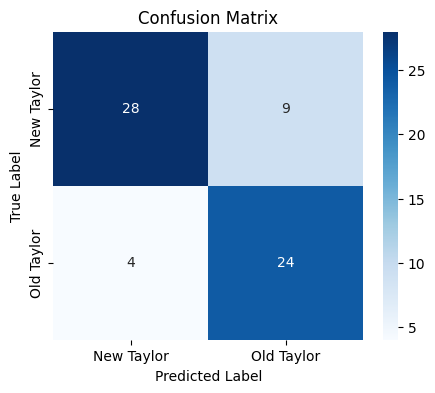

In [21]:
confusion = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(confusion, annot=True, cmap='Blues', xticklabels=['New Taylor', 'Old Taylor'], yticklabels=['New Taylor', 'Old Taylor'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

# Two-Sampled Z-test :3

In [22]:
for x in ["danceability", 'energy', 'loudness', 'acousticness', 'instrumentalness', 'valence', 'tempo', 'duration_ms']:
    
    print(f"Old Taylor {x} mean: {(round(np.mean(old_taylor[x]), 2))}")
    print(f"New Taylor {x} mean: {(round(np.mean(new_taylor[x]), 2))}")
    print(f"{x} z-score with p-value: {ztest(old_taylor[x], new_taylor[x], value=0)}")

Old Taylor danceability mean: 0.45
New Taylor danceability mean: 0.44
danceability z-score with p-value: (np.float64(1.7801071880621577), np.float64(0.07505842044893547))
Old Taylor energy mean: 0.35
New Taylor energy mean: 0.3
energy z-score with p-value: (np.float64(12.604644137092318), np.float64(1.9906907269840916e-36))
Old Taylor loudness mean: 0.23
New Taylor loudness mean: 0.32
loudness z-score with p-value: (np.float64(-11.119731829041076), np.float64(1.005738404735078e-28))
Old Taylor acousticness mean: 0.95
New Taylor acousticness mean: 0.96
acousticness z-score with p-value: (np.float64(-10.00485721524894), np.float64(1.4510085575638204e-23))
Old Taylor instrumentalness mean: 0.75
New Taylor instrumentalness mean: 0.77
instrumentalness z-score with p-value: (np.float64(-9.294462976029067), np.float64(1.47951177045205e-20))
Old Taylor valence mean: 0.71
New Taylor valence mean: 0.66
valence z-score with p-value: (np.float64(2.249827816873255), np.float64(0.024459877492517903)

Hmm, it seems not all variables in the dataset actually differ all that much between pre- and post-reputation. These variables introduce noise that could confuse our model...at a 5% significance level, this leaves us with the following variables that we can be reasonably sure change between conditions:

- Energy
- Loudness
- Acousticness
- Instrumentalness
- Valence
- Duration (ms)

Danceability and Tempo are probably introducing more noise than useable data. Let's see if we can get higher accuracy if we delete them!

## Second Attempt

In [ ]:
df9 = df8.drop(['danceability', 'tempo'], axis=1) # bye bye noise...

# no cheating...
X2 = df9.drop('old_taylor', axis=1).values
y2 = df9['old_taylor']

X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.3, random_state=42, stratify=y2)
X2_train_scaled = scaler.fit_transform(X2_train)
X2_test_scaled = scaler.transform(X2_test)

max2 = None
max_ind_kf2 = None
best_params2 = None

for fold in range(3, 10):
    kf2 = StratifiedKFold(n_splits=fold, shuffle=True, random_state=42)
    knn2_scaled = KNeighborsClassifier()
    knn2_cv = GridSearchCV(knn2_scaled, hyperparams, cv=kf2, scoring='f1')
    y2_pred = knn2_cv.predict(X2_test_scaled)

    if max2 is None or knn2_cv.best_score_ > max2:
            best_params2 = knn2_cv.best_params_
            max2 = knn2_cv.best_score_
            max_ind_kf2 = fold
            y2_pred_max = y2_pred

f1_result_2 = f1_score(y2_test, y2_pred_max, average='weighted')        
print(f"Best params: {best_params2}")
print(f"Best accuracy is {round(max2, 3)} at {max_ind_kf2} fold")
print(f"Weighted F1 Score: {round(f1_result_2, 3)}")

report2 = classification_report(y2_test, y2_pred_max)
print("Classification Report:\n", report2)

Best params: {'algorithm': 'ball_tree', 'metric': 'manhattan', 'n_neighbors': 7, 'weights': 'uniform'}
Best accuracy is 0.816 at 4 fold
Weighted F1 Score: 0.831
Classification Report:
               precision    recall  f1-score   support

         0.0       0.88      0.81      0.85        37
         1.0       0.77      0.86      0.81        28

    accuracy                           0.83        65
   macro avg       0.83      0.83      0.83        65
weighted avg       0.84      0.83      0.83        65



So awesome sauce! Dropping irrelevant variables improved our F1 score! Let's go back to our confusion matrix and see what's changed.

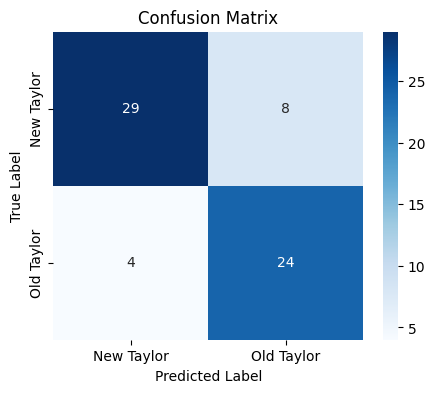

In [25]:
confusion = confusion_matrix(y2_test, y2_pred)

plt.figure(figsize=(5,4))
sns.heatmap(confusion, annot=True, cmap='Blues', xticklabels=['New Taylor', 'Old Taylor'], yticklabels=['New Taylor', 'Old Taylor'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

If you compare this confusion matrix with our first one, you'll see the only change is an extra correct prediction in the top left. Why do we even do anything anymore? How did the F1 score improve by 3 points over literally one data point shift? The top five Data Science Media sites (the DSM-5) cannot explain this.

## PCA Implementation

Le epic data visualization

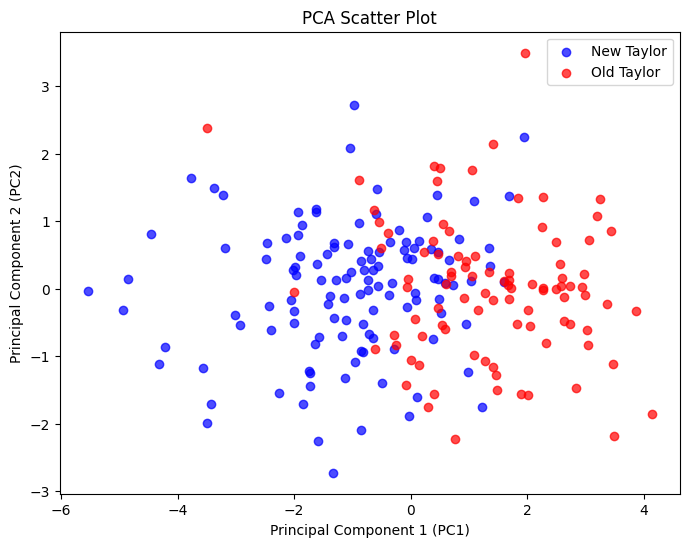

   energy  loudness  acousticness  instrumentalness  valence  duration_ms
0   0.527    -0.515        -0.410            -0.493    0.160        0.145
1  -0.108     0.101         0.202             0.030    0.604        0.756


In [26]:
pca = PCA(n_components=2)
data_scaled = scaler.fit_transform(df9)

pc = pca.fit_transform(data_scaled)

features = ['energy', 'loudness', 'acousticness', 'instrumentalness', 'valence', 'duration_ms'] 
X_pca = df9[features].values
scaler_pca = StandardScaler()

X_pca_scaled = scaler_pca.fit_transform(X_pca)
X_pca_small = pca.fit_transform(X_pca_scaled)

pc1 = X_pca_small[:, 0]
pc2 = X_pca_small[:, 1]

plt.figure(figsize=(8, 6))
plt.scatter(pc1[df9['old_taylor'] == 0], pc2[df9['old_taylor'] == 0], c='blue', label='New Taylor', alpha=0.7)
plt.scatter(pc1[df9['old_taylor'] != 0], pc2[df9['old_taylor'] != 0], c='red', label='Old Taylor', alpha=0.7)


plt.xlabel('Principal Component 1 (PC1)')
plt.ylabel('Principal Component 2 (PC2)')
plt.title('PCA Scatter Plot')
plt.legend()
plt.show()

pc_loadings = pd.DataFrame(pca.components_, columns=features).round(3)
print(pc_loadings)

Sure, I believe it! The scatter plot shows some clustering with non-trivial overlap in the middle as well as a bunch of outliers.

Component weights make sense in the context of our z-test also!! #DataWin

Let's see a bar chart with xkcd's sky blue because it's so pretty

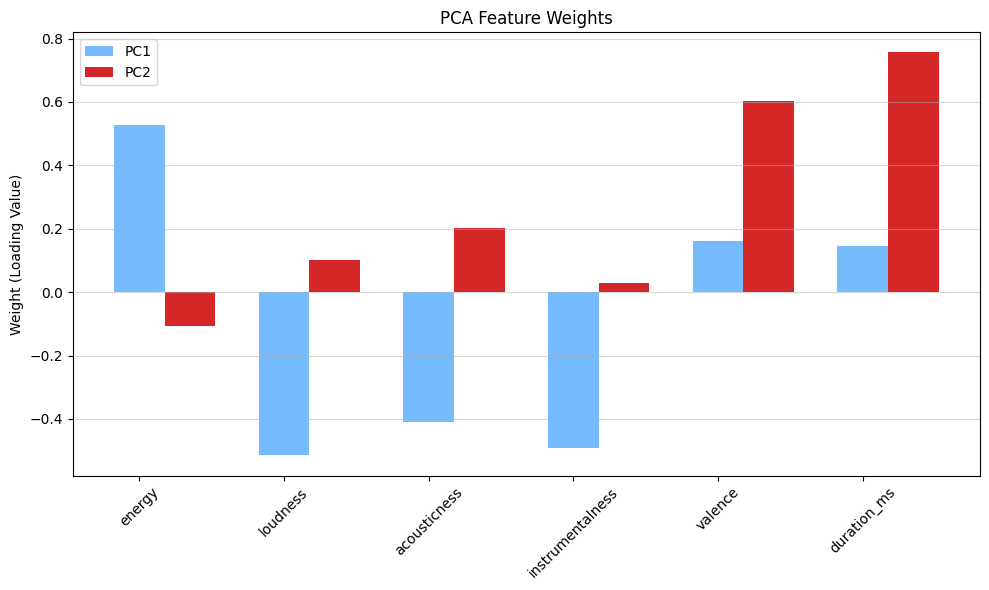

In [27]:
fig, ax = plt.subplots(figsize=(10, 6))
x_positions = np.arange(len(features))
pc1_weights = pc_loadings.iloc[0].values
pc2_weights = pc_loadings.iloc[1].values

for i in range(len(features)):
    width = 0.35
    ax.bar(x_positions[i], pc1_weights[i], width=width, color='xkcd:sky blue')
    ax.bar(x_positions[i] + width, pc2_weights[i], width=width, color='tab:red')

ax.set_xticks(x_positions)
ax.set_xticklabels(features, rotation=45)
ax.set_ylabel('Weight (Loading Value)')
ax.set_title(f'PCA Feature Weights')
ax.legend(labels=['PC1', 'PC2'])

plt.grid(axis='y', alpha=0.5)
plt.tight_layout()
plt.show()


See? Told you it'd look good

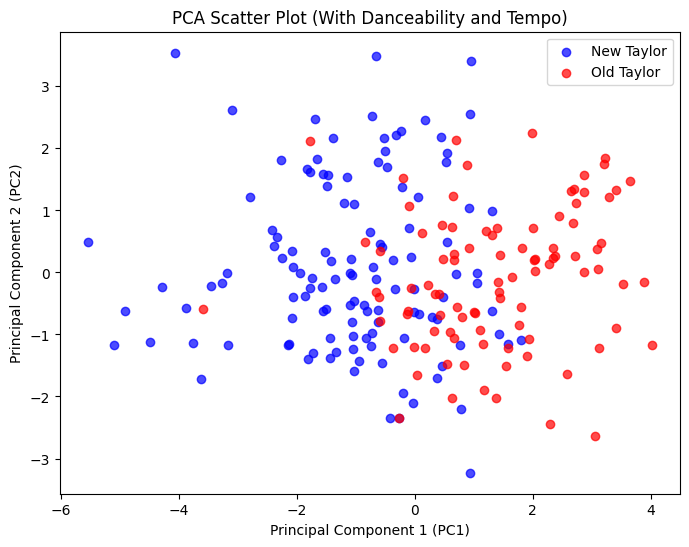

   energy  loudness  acousticness  instrumentalness  valence  duration_ms
0   0.527    -0.515        -0.410            -0.493    0.160        0.145
1  -0.108     0.101         0.202             0.030    0.604        0.756


In [30]:
pca = PCA(n_components=2)
pc = pca.fit_transform(data_scaled)

features_2 = ['energy', 'loudness', 'acousticness', 'instrumentalness', 'valence', 'duration_ms', 'tempo', 'danceability'] 
X_pca = df8[features_2].values
scaler_pca = StandardScaler()

X_pca_scaled = scaler_pca.fit_transform(X_pca)
X_pca_small = pca.fit_transform(X_pca_scaled)

pc1 = X_pca_small[:, 0]
pc2 = X_pca_small[:, 1]

plt.figure(figsize=(8, 6))
plt.scatter(pc1[df8['old_taylor'] == 0], pc2[df8['old_taylor'] == 0], c='blue', label='New Taylor', alpha=0.7)
plt.scatter(pc1[df8['old_taylor'] == 1], pc2[df8['old_taylor'] == 1], c='red', label='Old Taylor', alpha=0.7)


plt.xlabel('Principal Component 1 (PC1)')
plt.ylabel('Principal Component 2 (PC2)')
plt.title('PCA Scatter Plot (With Danceability and Tempo)')
plt.legend()
plt.show()

pc_loadings_2 = pd.DataFrame(pca.components_, columns=features_2).round(3)
print(pc_loadings)

EWWW UGLY LOW-VARIANCE ORTHOGONAL AXES

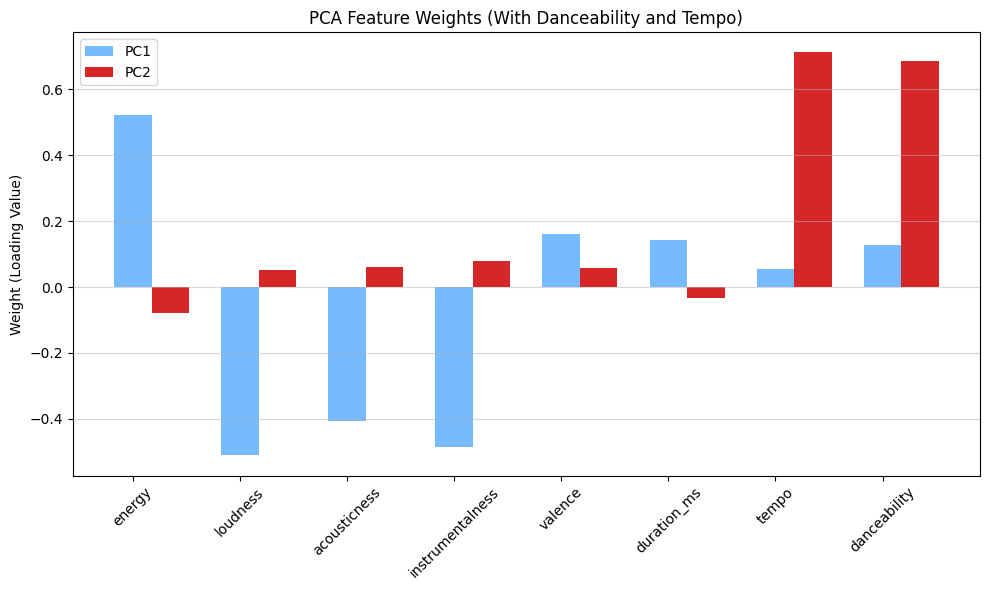

In [32]:
fig, ax = plt.subplots(figsize=(10, 6))
x_positions = np.arange(len(features_2))
pc1_weights = pc_loadings_2.iloc[0].values
pc2_weights = pc_loadings_2.iloc[1].values

for i in range(len(features_2)):
    width = 0.35
    ax.bar(x_positions[i], pc1_weights[i], width=width, color='xkcd:sky blue')
    ax.bar(x_positions[i] + width, pc2_weights[i], width=width, color='tab:red')

ax.set_xticks(x_positions)
ax.set_xticklabels(features_2, rotation=45)
ax.set_ylabel('Weight (Loading Value)')
ax.set_title(f'PCA Feature Weights (With Danceability and Tempo)')
ax.legend(labels=['PC1', 'PC2'])

plt.grid(axis='y', alpha=0.5)
plt.tight_layout()
plt.show()


# _Fin_